In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

try:
    sys.path.insert(0, str(Path('__file__').resolve().parents[1]))
except:
    sys.path.insert(0, str(Path.cwd().parent))
import shared
import preprocessing

import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Variables and paths
roi_bounds = (254110.36, 2820857.56, 254402.28, 2821060.56)
figs_dir = shared.OUT / "figures" / "space_syntax"
figs_dir.mkdir(parents=True, exist_ok=True)
raster_out = shared.OUT / "space_syntax_integration_subsampled.tif"
vector_out = shared.OUT / "vector_gis" / "space_syntax_axial_lines_subsampled.geojson"
vector_out.parent.mkdir(parents=True, exist_ok=True)

In [2]:
# Computation
footprints = preprocessing.load_footprints()
dem = shared.load_dem()
crs = dem["crs"]
if footprints.crs != crs:
    footprints = footprints.to_crs(crs)

skeleton, transform = shared.generate_free_space_skeleton(footprints, roi_bounds=roi_bounds, resolution=dem["res"])
axial_graph = shared.skeleton_to_axial_graph(skeleton, transform, crs)

if axial_graph.number_of_nodes() > 0:
    syntax_gdf = shared.compute_space_syntax_integration(axial_graph, transform, crs)
    integration_raster = shared.rasterize_integration(syntax_gdf, skeleton.shape, transform)

    profile = {
        'driver': 'GTiff', 'dtype': 'float32', 'nodata': 0.0,
        'width': skeleton.shape[1], 'height': skeleton.shape[0], 'count': 1,
        'crs': crs, 'transform': transform
    }
    with rasterio.open(raster_out, "w", **profile) as dst:
        dst.write(integration_raster, 1)
        
    syntax_gdf.to_file(str(vector_out), driver="GeoJSON")

Footprints: 263 polygons,  CRS: EPSG:32636
Loading DEM ...


  CRS=EPSG:32636  shape=(5138, 3902)  res=0.40 m  elev=65.2-145.0 m


  -> 18_space_syntax_integration_subsampled.png


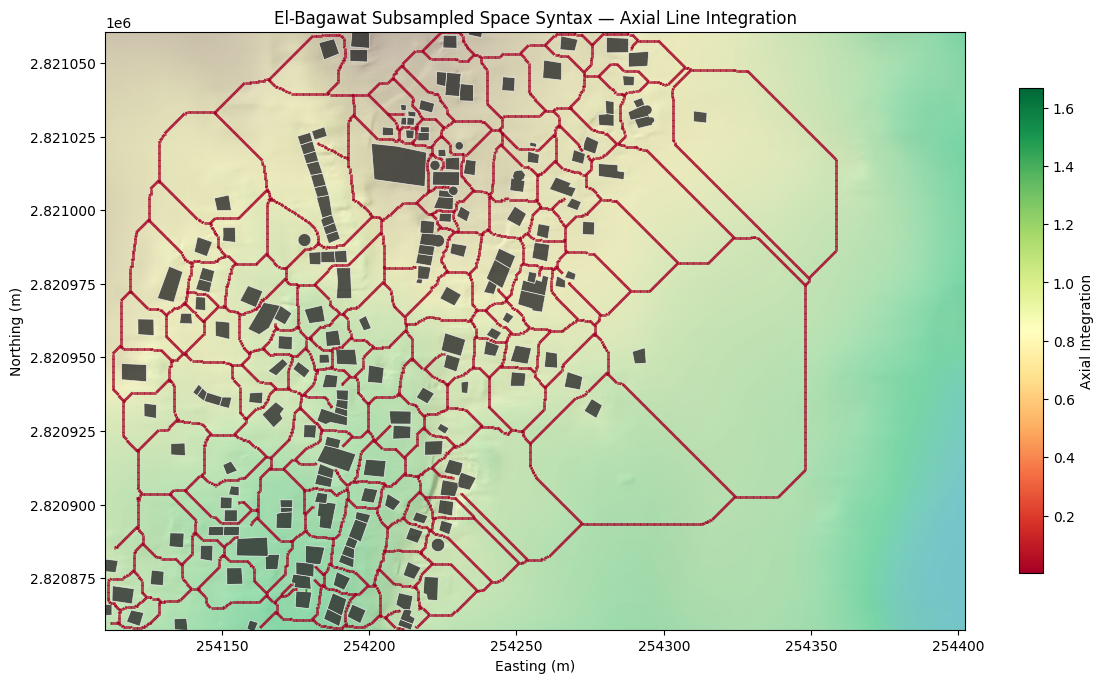

In [3]:
# Plotting
hillshade = shared.hillshade(dem["disp"])
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(dem["disp"], extent=dem["extent"], origin="upper", cmap="terrain", alpha=0.65, vmin=dem["e_min"], vmax=dem["e_max"])
ax.imshow(hillshade, extent=dem["extent"], origin="upper", cmap="gray", alpha=0.30)

if footprints is not None:
    footprints.plot(ax=ax, facecolor="#2c2c2c", edgecolor="white", linewidth=0.5, alpha=0.8)

try:
    doors = gpd.read_file(shared.OUT / "vector_gis" / "doors_native.shp")
    doors.plot(ax=ax, color="red", markersize=10, zorder=5)
except:
    pass

if "syntax_gdf" in locals() and not syntax_gdf.empty:
    norm_int = mcolors.Normalize(vmin=syntax_gdf["integration_mean"].min(), vmax=syntax_gdf["integration_mean"].max())
    syntax_gdf.plot(ax=ax, column="integration_mean", cmap="RdYlGn", linewidth=2, alpha=0.9, legend=True, legend_kwds={"label": "Axial Integration", "shrink": 0.5})
    
ax.set_xlim(roi_bounds[0], roi_bounds[2])
ax.set_ylim(roi_bounds[1], roi_bounds[3])
ax.set_title("El-Bagawat Subsampled Space Syntax â€” Axial Line Integration")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
shared.save_fig(figs_dir, "18_space_syntax_integration_subsampled.png", dpi=150)
plt.show()
